In [74]:
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9 
from plotnine import *
import pandas as pd
import math
import itertools


In [3]:
# Used ChatGPT and VSCode copilot AI to create a function of Euler's method that was fit for the SIR model 

def euler_SIR(S0, I0, R0, beta, gamma, Tmax, h):
    t = np.arange(0, Tmax + h, h) # giving full length of time
    n = len(t) # number of time steps

    S = np.zeros(n) # dictating how many steps 
    I = np.zeros(n)
    R = np.zeros(n)

    S[0] = S0 # setting beginning of S etc as 0
    I[0] = I0
    R[0] = R0

    N = S0 + I0 + R0 # total population

    for k in range(n - 1): # looping through time steps and calulating new derivates for each 
        dS = -beta * S[k] * I[k] / N 
        dI = beta * S[k] * I[k] / N - gamma * I[k]
        dR = gamma * I[k]

        S[k + 1] = S[k] + h*dS # updating S, I, R values for each step
        I[k + 1] = I[k] + h*dI
        R[k + 1] = R[k] + h*dR

    return t, S, I, R # returns time traversed and complete variables

In [4]:
# called with fake data. changed and played with to ensure it was working and better understand the relationship between the rates

if __name__ == "__main__":
    # Parameters
    S0 = 990     # initial susceptible
    I0 = 10      # initial infected
    R0 = 0       # initial recovered
    beta = .3   # infection rate
    gamma =.2  # recovery rate
    Tmax = 160   # days
    h = 1     # step size

    t, S, I, R = euler_SIR(S0, I0, R0, beta, gamma, Tmax, h)

results = pd.DataFrame({
    'Time': t,
    'Susceptible': S,
    'Infected': I,
    'Recovered': R
})

print(results.head())

   Time  Susceptible   Infected  Recovered
0     0   990.000000  10.000000   0.000000
1     1   987.030000  10.970000   2.000000
2     2   983.781684  12.024316   4.194000
3     3   980.232894  13.168243   6.598863
4     4   976.360510  14.406978   9.232512


In [56]:
# New Haven population = 137,000.
# On day 0, 1 person is infected
# Everyone is susceptible 
# Beta = 2, Gamma = 1
if __name__ == "__main__":
    # Parameters
    S0 = 136_999     # initial susceptible
    I0 = 1      # initial infected
    R0 = 0       # initial recovered
    beta = 2   # infection rate
    gamma = 1  # recovery rate
    Tmax = 30   # days
    h = 1     # step size

    t, S, I, R = euler_SIR(S0, I0, R0, beta, gamma, Tmax, h)

results = pd.DataFrame({
    'Time': t,
    'Susceptible': S,
    'Infected': I,
    'Recovered': R
})

print(results.tail())

    Time   Susceptible  Infected      Recovered
26    26  17986.691010  0.469824  119012.839167
27    27  17986.567644  0.123366  119013.308990
28    28  17986.535251  0.032393  119013.432356
29    29  17986.526745  0.008506  119013.464749
30    30  17986.524511  0.002233  119013.473255


In [57]:
# melt the results dataframe so it can be plotted with S, I, and R being individual lines
# ChatGPT how to name elements for melt and correct errors

results_plot = results.melt(id_vars=['Time'],value_vars=['Susceptible', 'Infected', 'Recovered'], var_name='SIR', value_name='Population')
print(results_plot.head())

   Time          SIR     Population
0     0  Susceptible  136999.000000
1     1  Susceptible  136997.000015
2     2  Susceptible  136993.000131
3     3  Susceptible  136985.000774
4     4  Susceptible  136969.003810


c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:630: PlotnineWarning: Saving 10 x 6 in image.
c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:631: PlotnineWarning: Filename: SIR_model.png


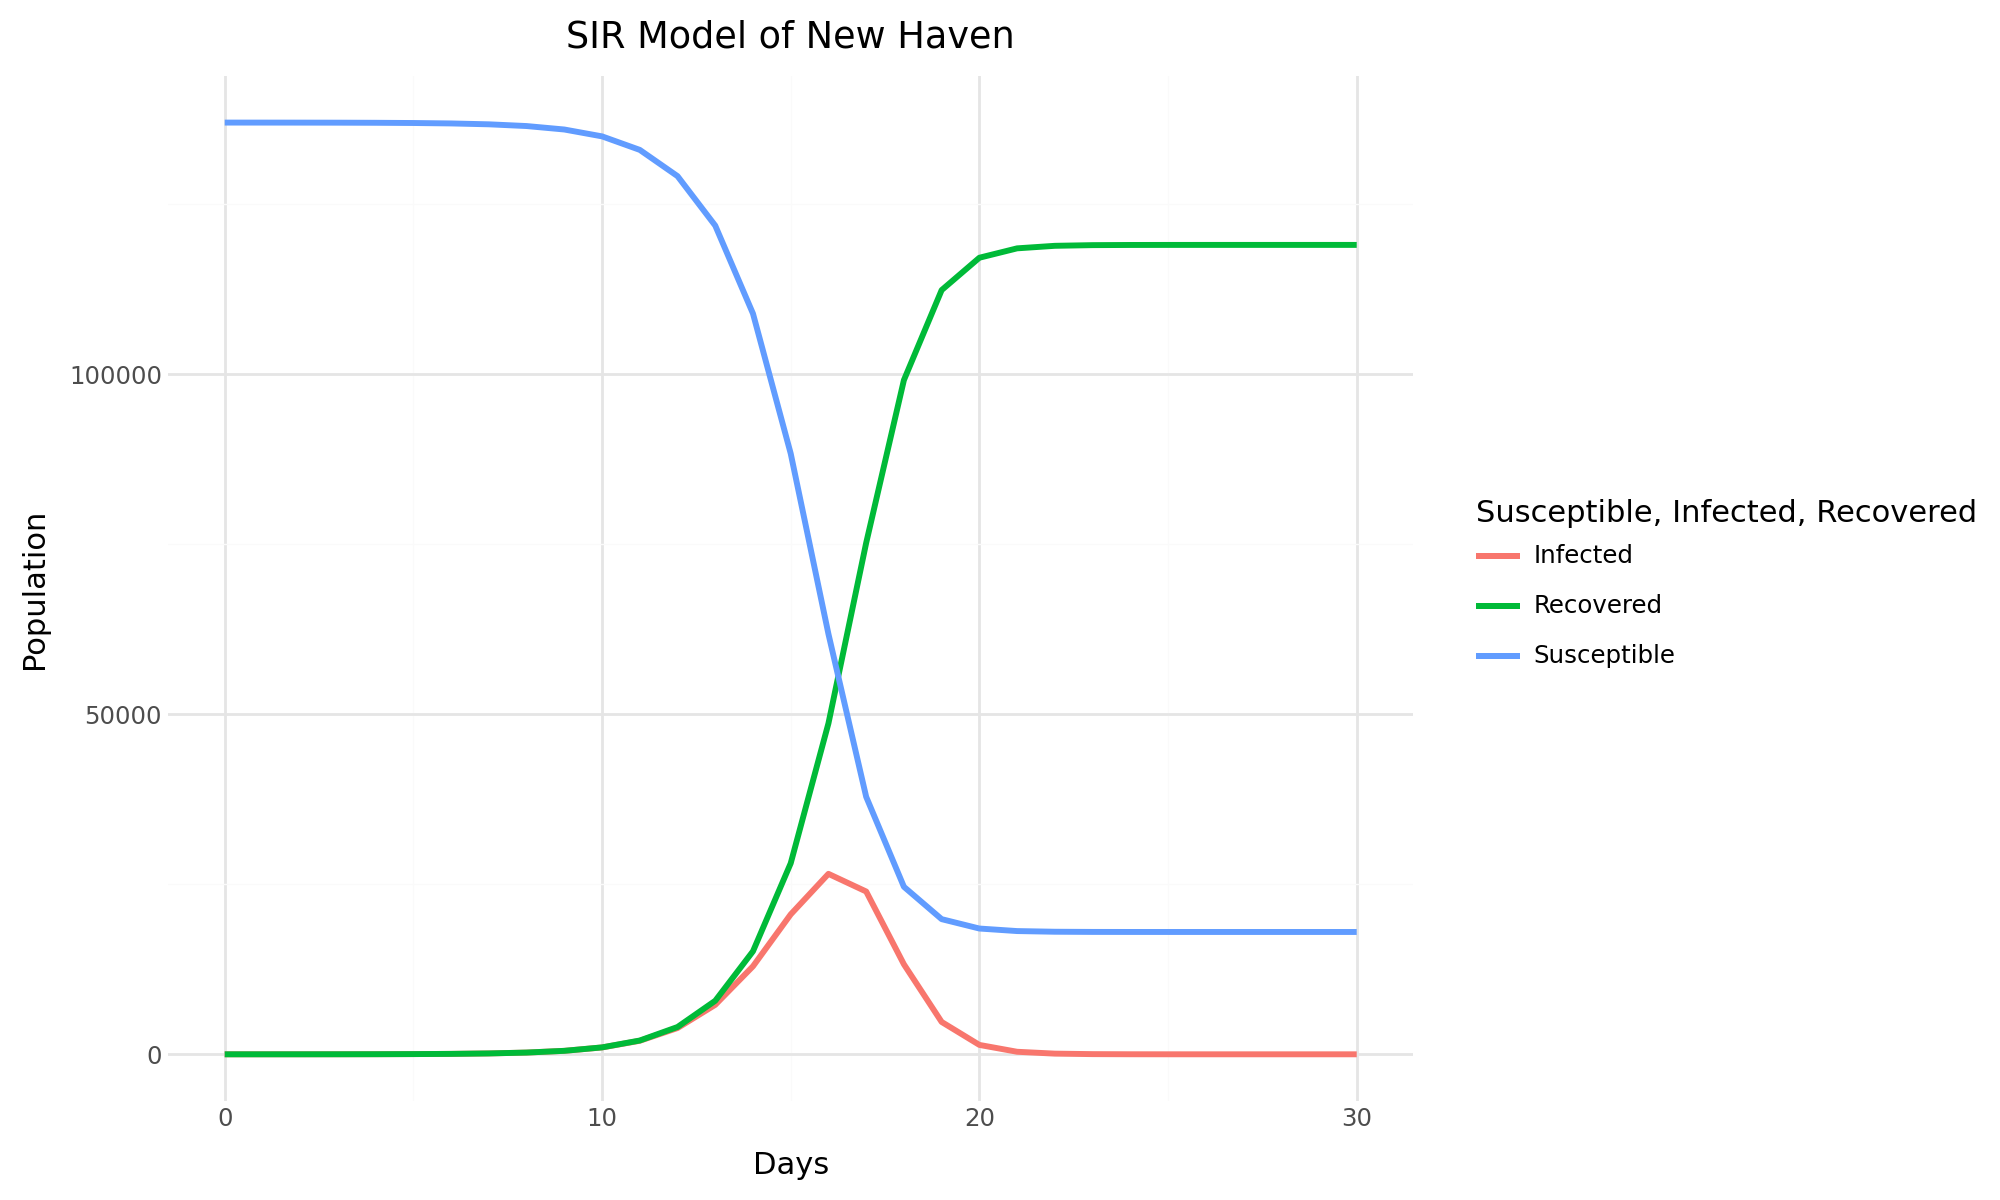

In [58]:
p = (
    ggplot(results_plot, aes(x='Time', y='Population', color='SIR'))
   + geom_line(size=1.2)
    + labs(
        title="SIR Model of New Haven",
        x="Days",
        y="Population",
        color="Susceptible, Infected, Recovered",
    )
    + theme_minimal()
    + theme(figure_size=(10, 6))
)

p.save('SIR_model.png')
p


In [ ]:
# Ensure plotting past when infected falls below 1
results.loc[results['Infected'] <1, 'Time'].min()
# the Infected rate drops below 1 on Day 26 - this code is not robust to if the rate of infection falls to 1 then jumps back up

26

In [85]:
# When does the number of infected people peak?
# Used ChatGPT to answer errors - output was as a numpy 
peak_day = results.loc[results['Infected'].idxmax(), 'Time']
print(f"Peak date: Day {peak_day}")

Peak date: Day 16


In [ ]:
# How many people are infected at peak?
number_peak = results.loc[peak_day, 'Infected']
print(f"Number of infected individuals at peak:{number_peak: .2f}")

Number of infected individuals at peak: 26533.15


In [73]:
# Number of individuals arguably cannot be decimals so I rounded up to get a  better capture of how many are infected
whole_number_peak=math.ceil(number_peak)
print(f"Rounding up, the number of individuals infected at the peak is {whole_number_peak}")

Rounding up, the number of individuals infected at the peak is 26534


In [108]:
# Vary Beta and Gamma
# Asked ChatGPT how I could vary the beta and gamma with a list of given values that tries every combination
 
if __name__ == "__main__":
    # Parameters
    S0 = 990     # initial susceptible
    I0 = 10      # initial infected
    R0 = 0       # initial recovered
    Tmax = 160   # days # always 160 days
    h = 1     # step size
    beta_values = [0.5, 1.0, 1.5, 2.0, 1.5, 3.0, 3.5] # varied beta values
    gamma_values = [0.25, 0.5, 0.75, 1.0, 1.25, 1.50, 1.75, 2.0] # varied gamma values

    all_results=[] # list to hold each run

    for beta, gamma in itertools.product(beta_values, gamma_values): # itertools.products allows iteration over all combinations of gamma and beta
        t, S, I, R = euler_SIR(S0, I0, R0, beta, gamma, Tmax, h)
        ind_results=pd.DataFrame({ # data frame of each iteration
            "Time": t,
            "Susceptible": S,
            "Infected": I,
            "Recovered": R,
            "Beta": beta,
            "Gamma": gamma
        })
        all_results.append(ind_results)

    pooled_results = pd.concat(all_results, ignore_index=True) # makes the list of all runs into a useable data frame

    print(pooled_results.head())
    print(pooled_results.tail())

   Time  Susceptible   Infected  Recovered  Beta  Gamma
0     0   990.000000  10.000000   0.000000   0.5   0.25
1     1   985.050000  12.450000   2.500000   0.5   0.25
2     2   978.918064  15.469436   5.612500   0.5   0.25
3     3   971.346408  19.173732   9.479859   0.5   0.25
4     4   962.034240  23.692467  14.273292   0.5   0.25
      Time  Susceptible      Infected   Recovered  Beta  Gamma
9011   156   129.725005 -1.180725e-38  870.274995   3.5    2.0
9012   157   129.725005  6.446316e-39  870.274995   3.5    2.0
9013   158   129.725005 -3.519447e-39  870.274995   3.5    2.0
9014   159   129.725005  1.921486e-39  870.274995   3.5    2.0
9015   160   129.725005 -1.049059e-39  870.274995   3.5    2.0


C:\Users\carol\AppData\Local\Temp\ipykernel_29432\709158174.py:18: RuntimeWarning: overflow encountered in scalar multiply
C:\Users\carol\AppData\Local\Temp\ipykernel_29432\709158174.py:19: RuntimeWarning: overflow encountered in scalar multiply
C:\Users\carol\AppData\Local\Temp\ipykernel_29432\709158174.py:19: RuntimeWarning: invalid value encountered in scalar subtract


In [109]:
print(pooled_results[['Beta','Gamma',]].drop_duplicates()) # print beta gamme combinations to ensure all ran 

      Beta  Gamma
0      0.5   0.25
161    0.5   0.50
322    0.5   0.75
483    0.5   1.00
644    0.5   1.25
805    0.5   1.50
966    0.5   1.75
1127   0.5   2.00
1288   1.0   0.25
1449   1.0   0.50
1610   1.0   0.75
1771   1.0   1.00
1932   1.0   1.25
2093   1.0   1.50
2254   1.0   1.75
2415   1.0   2.00
2576   1.5   0.25
2737   1.5   0.50
2898   1.5   0.75
3059   1.5   1.00
3220   1.5   1.25
3381   1.5   1.50
3542   1.5   1.75
3703   1.5   2.00
3864   2.0   0.25
4025   2.0   0.50
4186   2.0   0.75
4347   2.0   1.00
4508   2.0   1.25
4669   2.0   1.50
4830   2.0   1.75
4991   2.0   2.00
6440   3.0   0.25
6601   3.0   0.50
6762   3.0   0.75
6923   3.0   1.00
7084   3.0   1.25
7245   3.0   1.50
7406   3.0   1.75
7567   3.0   2.00
7728   3.5   0.25
7889   3.5   0.50
8050   3.5   0.75
8211   3.5   1.00
8372   3.5   1.25
8533   3.5   1.50
8694   3.5   1.75
8855   3.5   2.00


In [110]:
# From ChatGPT - how to retain peak date and number peaked for each iteration 
peak_dates = []

for (beta, gamma), group in pooled_results.groupby(['Beta', 'Gamma']): # for each combination of beta gamma
    peak_day = group.loc[group['Infected'].idxmax(), 'Time']
    number_peak = group.loc[group['Time'] == peak_day, 'Infected'].values[0]
    whole_number_peak=math.ceil(number_peak)
    peak_dates.append({
        'Beta': beta,
        'Gamma': gamma,
        'Peak_Day': peak_day,
        'Peak_Infected': whole_number_peak
    })
peak_dates_df = pd.DataFrame(peak_dates)  
print(peak_dates_df)  


    Beta  Gamma  Peak_Day  Peak_Infected
0    0.5   0.25        19            169
1    0.5   0.50         0             10
2    0.5   0.75         0             10
3    0.5   1.00         0             10
4    0.5   1.25         0             10
5    0.5   1.50         0             10
6    0.5   1.75         0             10
7    0.5   2.00         0             10
8    1.0   0.25         9            462
9    1.0   0.50        10            180
10   1.0   0.75        11             46
11   1.0   1.00         0             10
12   1.0   1.25         0             10
13   1.0   1.50         0             10
14   1.0   1.75         0             10
15   1.0   2.00         0             10
16   1.5   0.25         7            628
17   1.5   0.50         7            373
18   1.5   0.75         7            191
19   1.5   1.00         8             80
20   1.5   1.25         7             26
21   1.5   1.50         0             10
22   1.5   1.75         0             10
23   1.5   2.00 

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:630: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:631: PlotnineWarning: Filename: peak_days_heatmap.png


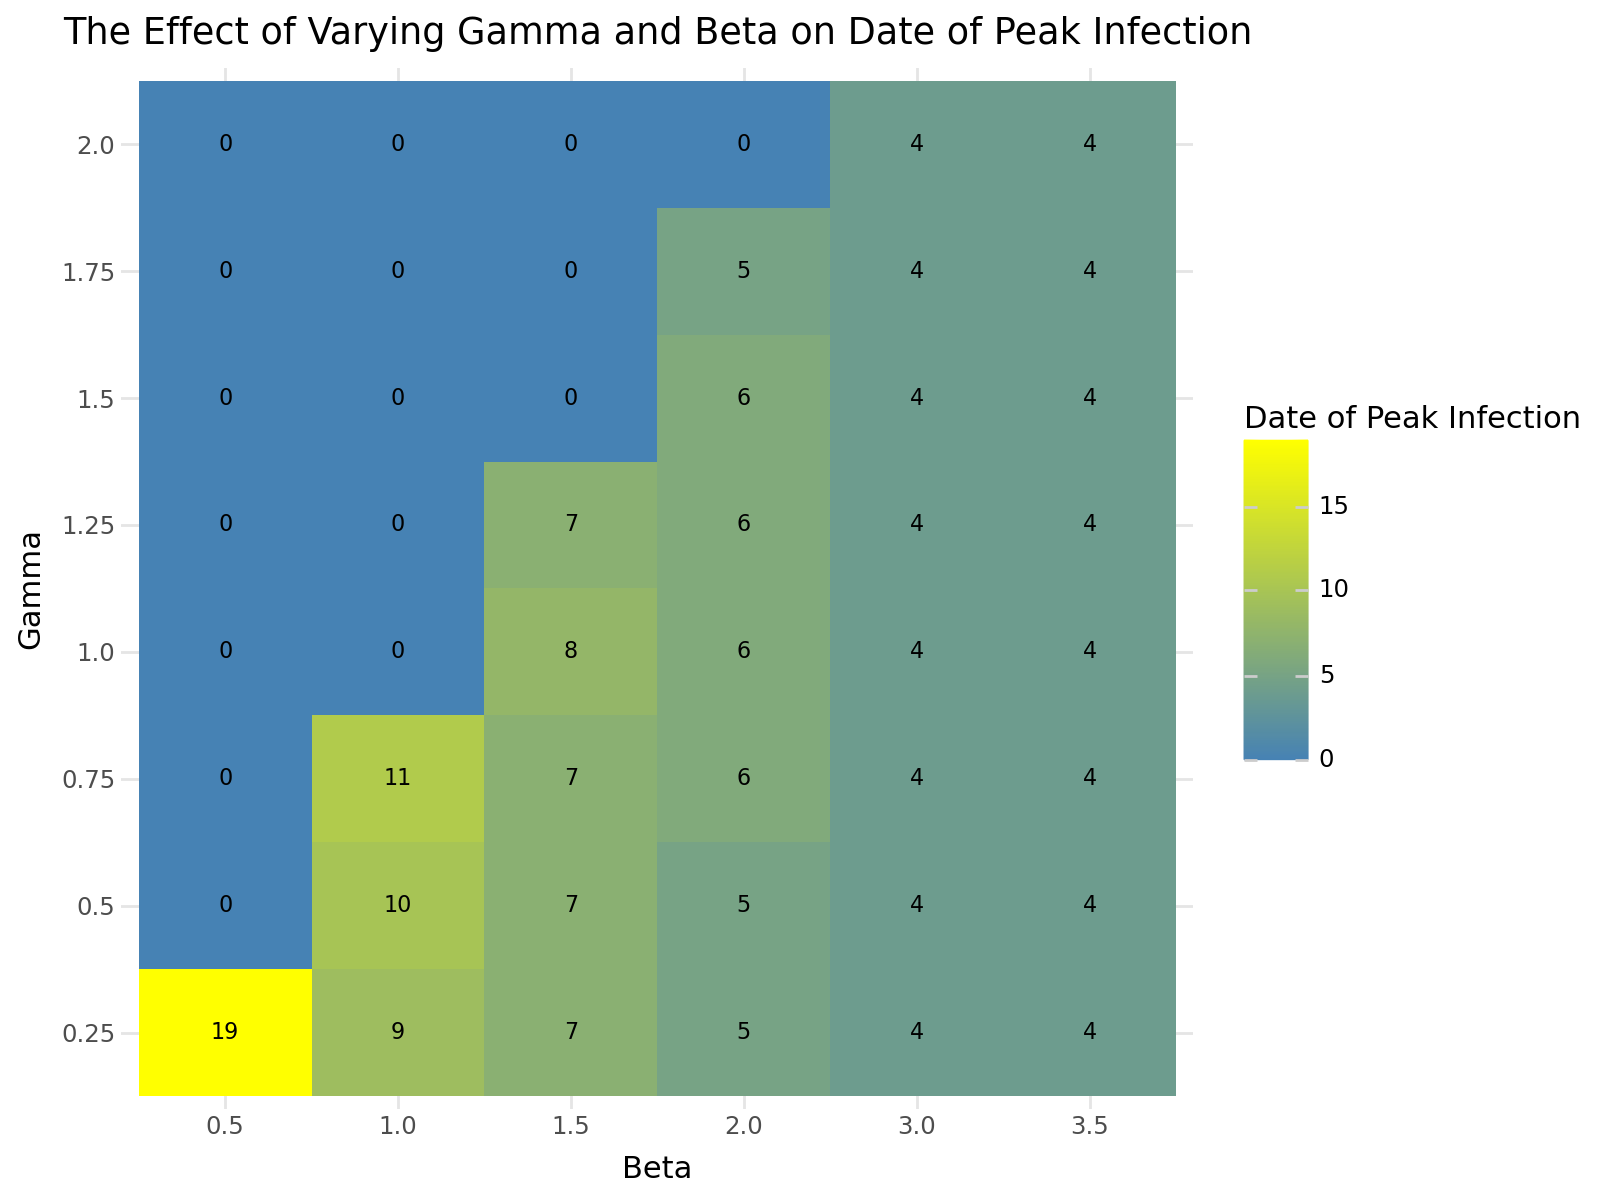

In [124]:
l = (ggplot(peak_dates_df, aes(x='factor(Beta)', y='factor(Gamma)', fill='Peak_Day'))
+ geom_tile()
+ geom_text(aes(label='Peak_Day'), color='black', size=8)
+ scale_fill_gradient(low='steelblue', high='yellow', name='Date of Peak Infection')
+ labs (
    title ='The Effect of Varying Gamma and Beta on Date of Peak Infection',
    x = 'Beta',
    y ='Gamma',
)
+ theme_minimal()
+ theme(figure_size = (8,6))
)



l.save('peak_days_heatmap.png')
l


c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:630: PlotnineWarning: Saving 10 x 6 in image.
c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:631: PlotnineWarning: Filename: peak_number_heatmap.png


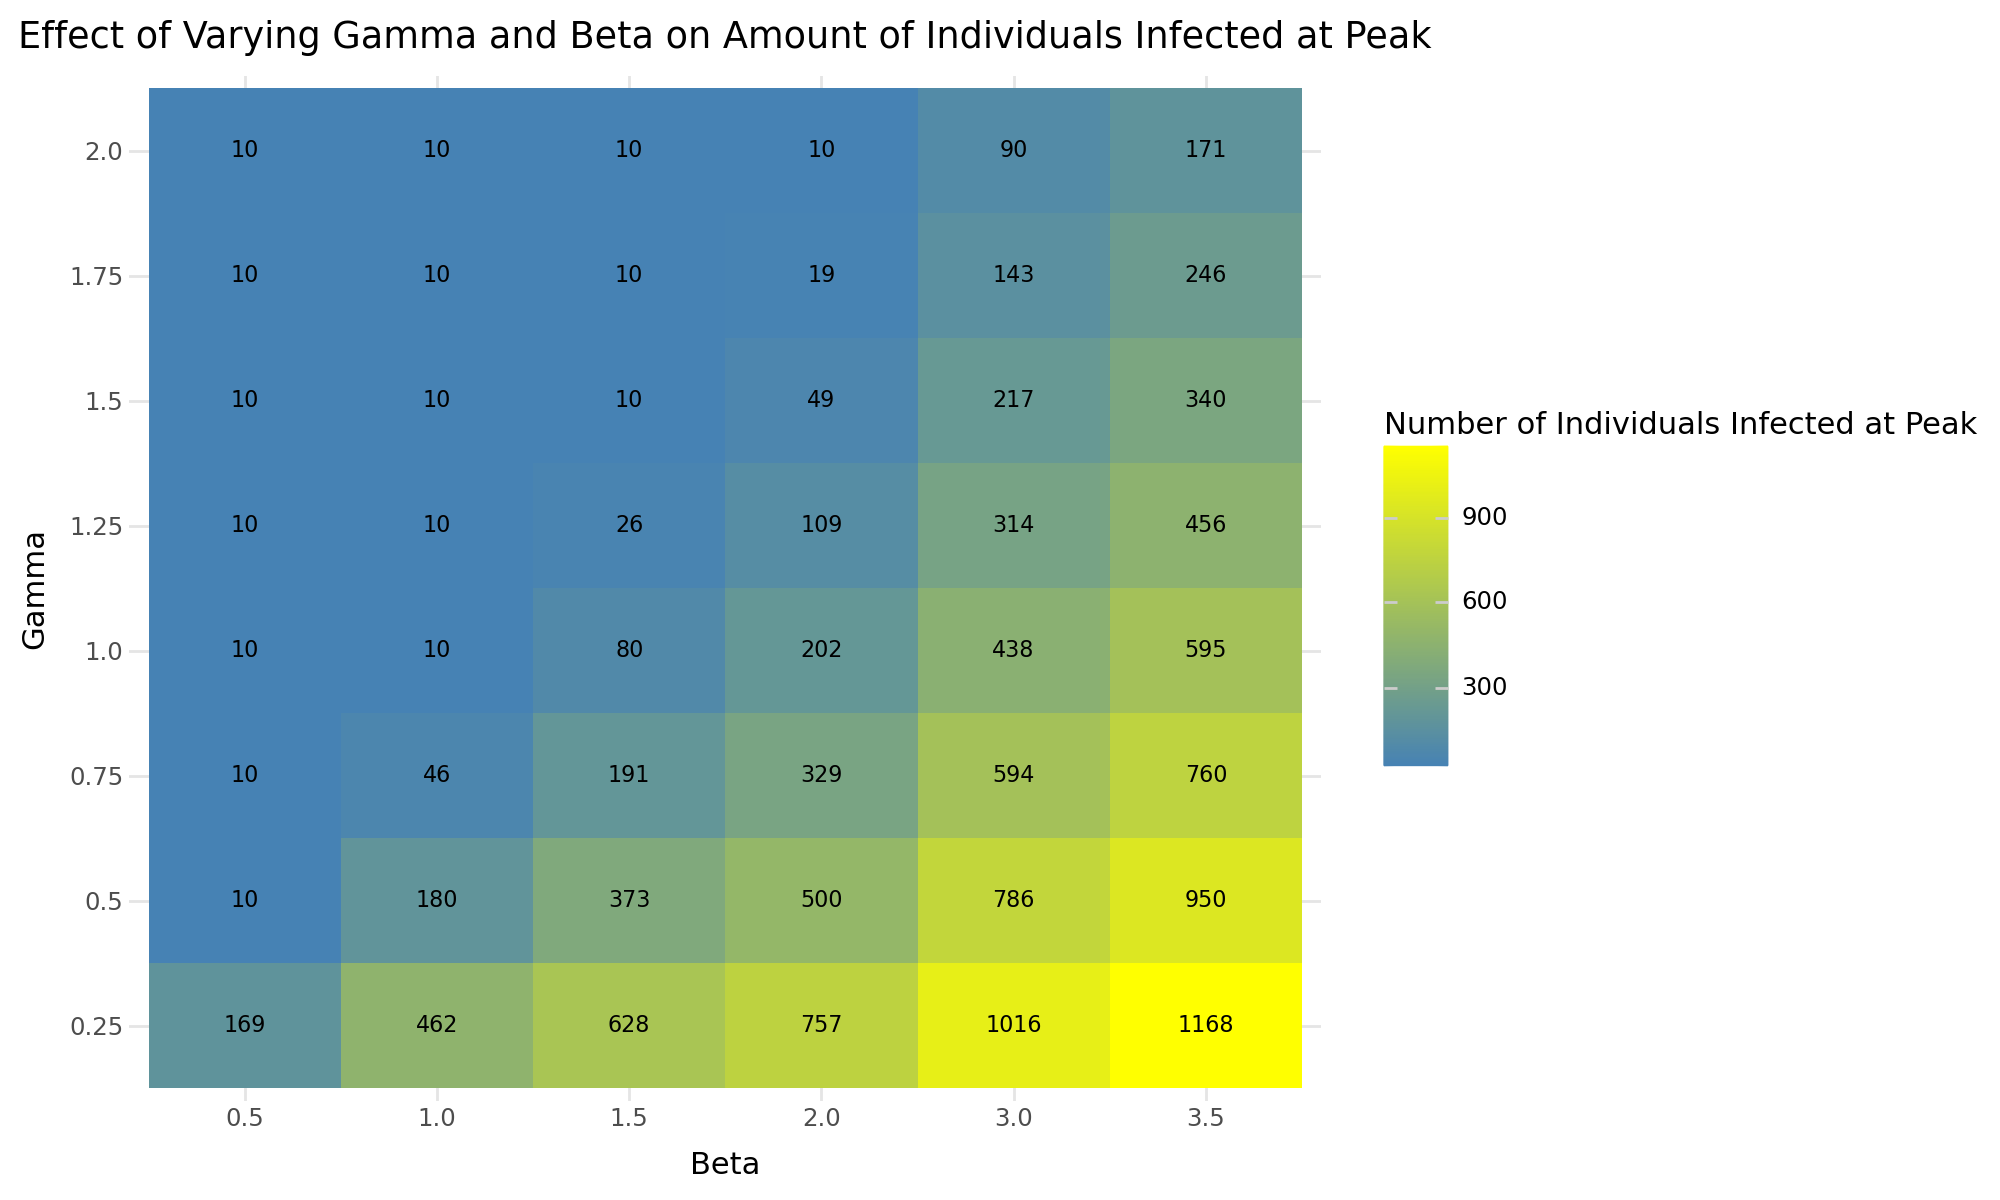

In [ ]:
# used ChatGPT to 

m = (ggplot(peak_dates_df, aes(x='factor(Beta)', y='factor(Gamma)', fill='Peak_Infected'))
+ geom_tile()
+ geom_text(aes(label='Peak_Infected'), color='black', size=8)
+ scale_fill_gradient(low='steelblue', high='yellow', name='Number of Individuals Infected at Peak')
+ labs (
    title ='Effect of Varying Gamma and Beta on Amount of Individuals Infected at Peak',
    x = 'Beta',
    y ='Gamma',
)
+ theme_minimal()
+ theme(figure_size=(10,6))
)

m.save('peak_number_heatmap.png')
m